In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
data_dir = '/content/drive/MyDrive/RealWaste'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import os


In [ ]:
IMG_HEIGHT = 160
IMG_WIDTH = 160
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())


Found 3803 images belonging to 9 classes.
Found 949 images belonging to 9 classes.


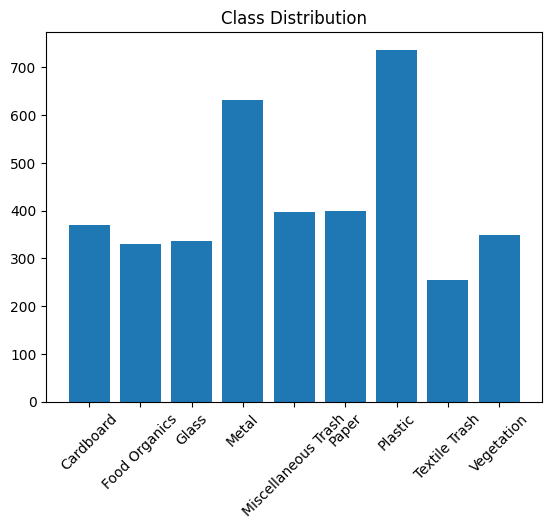

In [ ]:
labels = train_data.classes
weights = compute_class_weight(class_weight='balanced',
                                classes=np.unique(labels),
                                y=labels)
class_weight_dict = dict(enumerate(weights))

# Optional: Plot distribution
plt.bar(class_names, np.bincount(labels))
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()


In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=2,
                              verbose=1,
                              min_lr=1e-6)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,  # Increased from 12
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_reduce]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 2087s 18s/step - accuracy: 0.2324 - loss: 2.1561 - val_accuracy: 0.5037 - val_loss: 1.5091 - learning_rate: 1.0000e-04
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 60s 502ms/step - accuracy: 0.5430 - loss: 1.2751 - val_accuracy: 0.5311 - val_loss: 1.3703 - learning_rate: 1.0000e-04
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 81s 491ms/step - accuracy: 0.6104 - loss: 1.0366 - val_accuracy: 0.5332 - val_loss: 1.3597 - learning_rate: 1.0000e-04
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 58s 485ms/step - accuracy: 0.6634 - loss: 0.9355 - val_accuracy: 0.5722 - val_loss: 1.2906 - learning_rate: 1.0000e-04
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 58s 487ms/step - accuracy: 0.6724 - loss: 0.8614 - val_accuracy: 0.5711 - val_loss: 1.2866 - learning_rate: 1.0000e-04
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 495ms/step - accuracy: 0.6969 - loss: 0.8350 - val_accuracy: 0.5901 - val_loss: 1.2244 - learning_rate: 1.0000e-04
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 49

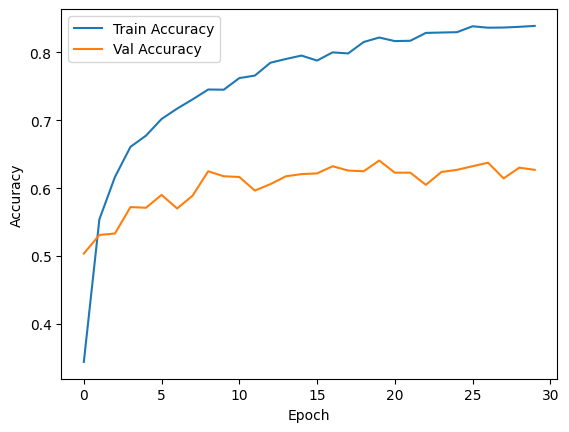

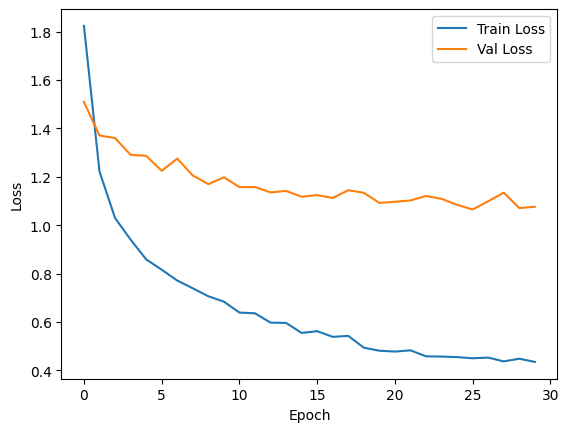

In [ ]:
# ✅ Step 10: Plot accuracy and loss graphs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# ✅ Step 11: Evaluate with classification report
val_data.reset()
preds = model.predict(val_data)
predicted_classes = np.argmax(preds, axis=1)
true_classes = val_data.classesa

print(classification_report(true_classes, predicted_classes, target_names=class_names))


30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 372ms/step
                     precision    recall  f1-score   support

          Cardboard       0.44      0.25      0.32        92
      Food Organics       0.76      0.87      0.81        82
              Glass       0.80      0.80      0.80        84
              Metal       0.60      0.76      0.67       158
Miscellaneous Trash       0.44      0.54      0.48        99
              Paper       0.64      0.58      0.61       100
            Plastic       0.66      0.49      0.56       184
      Textile Trash       0.46      0.60      0.52        63
         Vegetation       0.89      0.91      0.90        87

           accuracy                           0.63       949
          macro avg       0.63      0.64      0.63       949
       weighted avg       0.63      0.63      0.62       949



In [ ]:

# ✅ Step 12: Save the model
model.save("mobilenet_waste_classifier.h5")


30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step


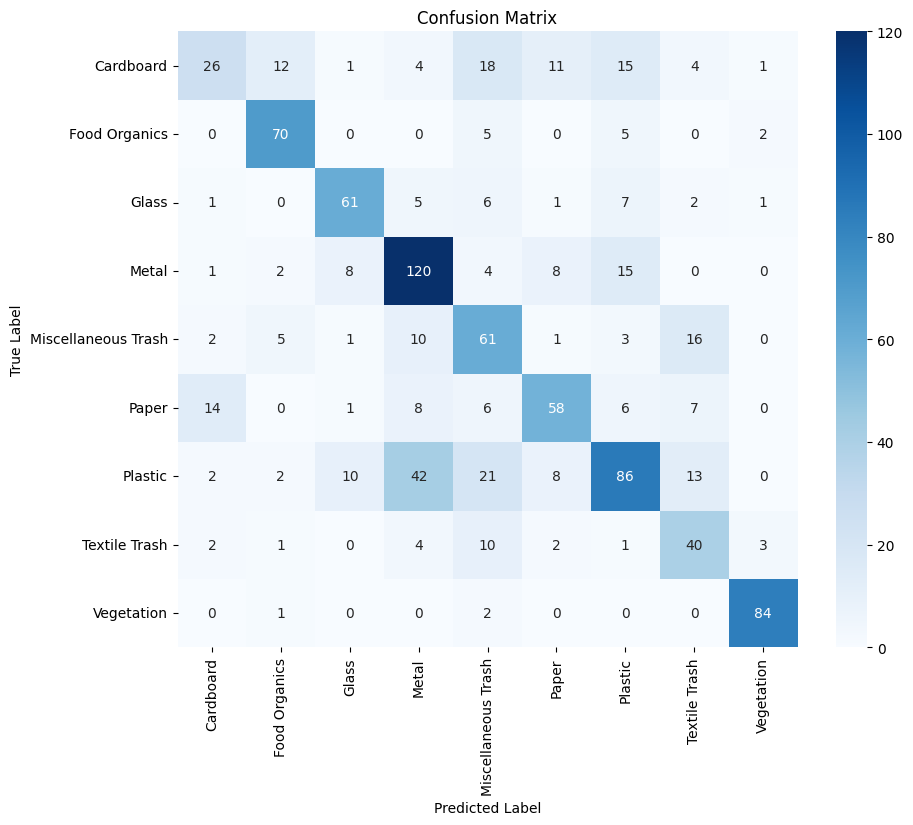

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on validation data
y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes

# Get class labels
class_labels = list(val_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    print(f"Predicted Class: {predicted_class} ({confidence:.2f}%)")

# ✅ Call the function like this:
predict_image('/content/Vegetation_13.jpg')


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: Vegetation (90.96%)
